# Preliminary Data Analysis - Exploratory Data Analysis (EDA)

This notebook performs comprehensive exploratory data analysis on the training and test datasets to understand feature characteristics, distributions, and data quality issues.

## 1) Imports and plotting configuration

This cell imports standard data analysis libraries (pandas, numpy), plotting libraries (matplotlib, seaborn), and the helper `load_csv_data`. Warnings are suppressed for clearer output and plotting style is set.

In [ ]:
# Import required libraries for data analysis and visualization
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from helpers import load_csv_data
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

## 2) Load datasets

Load x_train, y_train and x_test using the provided helper. Confirm shapes to ensure files loaded correctly and to understand dataset sizes.

In [2]:
# Load datasets using the helper function
print("Loading datasets...")
x_train, x_test,y_train,  _, _ = load_csv_data('dataset')

print(f"Training features shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test features shape: {x_test.shape}")

Loading datasets...



KeyboardInterrupt



### 2.1) Alternative function to read in data 

Reads in the data into Pandas dataframe. 

In [3]:
#define path to the dataset
data_path = r"C:\Users\aleks\ML\data\dataset\dataset"

In [4]:
#define function to load all csv files in a folder as arrays
def load_csvs_as_arrays(folder_path):
    """
    Reads all CSV files inside a folder and returns them as a list of pandas DataFrames.
    
    Parameters:
        folder_path (str): Path to the folder containing CSV files.
    
    Returns:
        list: list of pandas DataFrames, one per CSV file
    """
    arrays = []
    
    # Get all CSV files in the folder (non-recursive)
    csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]
    
    for file in csv_files:
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)
        arrays.append(df)
    
    return arrays

In [5]:
array_of_arrays=load_csvs_as_arrays(data_path)

Convert data to NP arrays.

In [6]:
# convert to np arrrays
x_train=np.array(array_of_arrays[2])
x_test=np.array(array_of_arrays[1])
y_train=np.array(array_of_arrays[3])

Make a Pandas version.

In [7]:
# pandas DataFrame version
x_train_df=array_of_arrays[2]
x_test_df=array_of_arrays[1]
y_train_df=array_of_arrays[3]

In [8]:
print(f"Training features shape: {x_train.shape}")
print(f"Training y shape: {y_train.shape}")
print(f"Test features shape: {x_test.shape}")

Training features shape: (328135, 322)
Training y shape: (328135, 2)
Test features shape: (109379, 322)


### 2.2) Sample extraction

In [9]:
# define sample to be taken for analysis
row_n_start=0
row_n_final=15000

Np arrays sample

In [10]:
# make numpy sub_arrays
x_train_sample=x_train[row_n_start:row_n_final,:]
x_test_sample=x_test[row_n_start:row_n_final,:]
y_train_sample=y_train[row_n_start:row_n_final,:]

Pandas sample

In [11]:
# make pandas sub_arrays
x_tr_sample_df=x_train_df.iloc[row_n_start:row_n_final,:]
x_test_sample_df=x_test_df.iloc[row_n_start:row_n_final,:]
y_tr_sample_df=y_train_df.iloc[row_n_start:row_n_final,:]


### 2.3) Loading labels

In [18]:
def extract_labels(csv_path):
    """
    Extract the header labels from a CSV file using NumPy only.
    
    Parameters:
        csv_path (str): Path to the CSV file.
    
    Returns:
        list: List of column labels as strings.
    """
    with open(csv_path, 'r') as f:
        # Read the first line only (the header row)
        header = f.readline().strip()
    # Split by comma to get labels
    labels = np.array(header.split(','))
    return labels.tolist()

In [20]:
labels=extract_labels(os.path.join(data_path, "x_train.csv"))

In [21]:
print(len(labels))

322


## 3) Dataset overview and basic statistics

Show head, info and descriptive statistics for numerical features to get an initial sense of the data, types and value ranges.

In [5]:
# Display basic dataset information
print("=== TRAINING DATA OVERVIEW ===")
print("\nFirst 5 rows of training features:")
display(x_train[:5, :15])

print("\nTraining data info:")
print(x_train[0])

# print("\nBasic statistics for numerical features:")
# display(x_train.describe())

print("\n=== TARGET VARIABLE ===")
print("First 5 target values:")
display(y_train[0:10])
print(f"\nTarget variable info:")
print(y_train[1])

=== TRAINING DATA OVERVIEW ===

First 5 rows of training features:


array([[5.30000000e+01, 1.10000000e+01, 1.11620150e+07, 1.10000000e+01,
        1.60000000e+01, 2.01500000e+03, 1.10000000e+03, 2.01501563e+09,
        2.01501563e+09,            nan,            nan,            nan,
                   nan,            nan,            nan],
       [3.30000000e+01, 1.20000000e+01, 1.21520150e+07, 1.20000000e+01,
        1.50000000e+01, 2.01500000e+03, 1.20000000e+03, 2.01500439e+09,
        2.01500439e+09, 1.00000000e+00, 1.00000000e+00,            nan,
        1.00000000e+00, 1.00000000e+00,            nan],
       [2.00000000e+01, 1.00000000e+01, 1.02020150e+07, 1.00000000e+01,
        2.00000000e+01, 2.01500000e+03, 1.10000000e+03, 2.01500564e+09,
        2.01500564e+09, 1.00000000e+00, 1.00000000e+00,            nan,
        1.00000000e+00, 2.00000000e+00,            nan],
       [4.20000000e+01, 6.00000000e+00, 6.18201500e+06, 6.00000000e+00,
        1.80000000e+01, 2.01500000e+03, 1.10000000e+03, 2.01500469e+09,
        2.01500469e+09,            na


Training data info:
[5.30000000e+01 1.10000000e+01 1.11620150e+07 1.10000000e+01
 1.60000000e+01 2.01500000e+03 1.10000000e+03 2.01501563e+09
 2.01501563e+09            nan            nan            nan
            nan            nan            nan            nan
            nan            nan 1.00000000e+00 1.00000000e+00
 2.00000000e+00 1.00000000e+00            nan 1.00000000e+00
 1.00000000e+00 2.00000000e+00 2.00000000e+00 1.00000000e+00
 5.00000000e+00 8.80000000e+01 1.00000000e+00 1.00000000e+00
 2.00000000e+00 1.00000000e+00 3.00000000e+00            nan
 1.00000000e+00 1.00000000e+00 2.00000000e+00 2.00000000e+00
 2.00000000e+00            nan 2.00000000e+00 2.00000000e+00
 2.00000000e+00 2.00000000e+00 1.00000000e+00 2.00000000e+00
 3.00000000e+00            nan 2.00000000e+00 1.00000000e+00
 5.00000000e+00 1.00000000e+00            nan            nan
            nan 2.00000000e+00 1.00000000e+00 8.80000000e+01
 8.00000000e+00 1.00000000e+00 1.10000000e+02 5.01000000e+02
   

array([-1, -1, -1, -1, -1, -1,  1,  1, -1, -1])


Target variable info:
-1


## 4) Feature type identification

Determine which columns are continuous vs categorical. Numerical columns with a small number of unique values (≤10) are flagged as potential categorical features. This helps choose appropriate visualizations and preprocessing.

In [47]:
# Feature type identification: Continuous vs Categorical
print("=== FEATURE TYPE ANALYSIS ===")

# Identify numerical and categorical features
numerical_features = x_train_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = x_train_df.select_dtypes(include=['object', 'category']).columns.tolist()

# For numerical features, check if they might be categorical (low unique values)
potential_categorical = []
true_continuous = []

for col in numerical_features:
    unique_values = x_train_df[col].nunique()
    if unique_values <= 10:  # Threshold for categorical
        potential_categorical.append(col)
    else:
        true_continuous.append(col)

print(f"Identified continuous features ({len(true_continuous)}): {true_continuous}")
print(f"Identified categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Potential categorical (numerical with ≤10 unique values) ({len(potential_categorical)}): {potential_categorical}")

# Create feature type dictionary for later use
feature_types = {
    'continuous': true_continuous,
    'categorical': categorical_features + potential_categorical
}

=== FEATURE TYPE ANALYSIS ===
Identified continuous features (103): ['Id', '_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'SEQNO', '_PSU', 'NUMADULT', 'NUMMEN', 'NUMWOMEN', 'HHADULT', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'DIABAGE2', 'CHILDREN', 'WEIGHT2', 'HEIGHT3', 'ALCDAY5', 'AVEDRNK2', 'DRNK3GE5', 'MAXDRNKS', 'FRUITJU1', 'FRUIT1', 'FVBEANS', 'FVGREEN', 'FVORANG', 'VEGETAB1', 'EXRACT11', 'EXEROFT1', 'EXERHMM1', 'EXRACT21', 'EXEROFT2', 'EXERHMM2', 'STRENGTH', 'JOINPAIN', 'FLSHTMY2', 'IMFVPLAC', 'HIVTSTD3', 'WHRTST10', 'BLDSUGAR', 'FEETCHK2', 'DOCTDIAB', 'CHKHEMO3', 'FEETCHK', 'CRGVREL1', 'CRGVPRB1', 'LONGWTCH', 'ASTHMAGE', 'ASDRVIST', 'ASRCHKUP', 'ASACTLIM', 'SCNTWRK1', 'SCNTLWK1', 'ADPLEASR', 'ADDOWN', 'ADSLEEP', 'ADENERGY', 'ADEAT1', 'ADFAIL', 'ADTHINK', 'ADMOVE', '_STSTR', '_STRWT', '_RAWRAKE', '_WT2RAKE', '_CLLCPWT', '_DUALCOR', '_LLCPWT', '_AGEG5YR', '_AGE80', 'HTIN4', 'HTM4', 'WTKG3', '_BMI5', 'DROCDY3_', '_DRNKWEK', 'FTJUDA1_', 'FRUTDA1_', 'BEANDAY_', 'GRENDAY_', 'ORNGDAY_', 'VE

## 5) Checking for correlations between features and target

In [54]:
# Explore correlations between features and target
print("=== FEATURE CORRELATION ANALYSIS ===")

# Calculate correlations
correlations = x_tr_sample_df.corrwith(y_tr_sample_df[0])

# Use absolute correlations to pick top features
correlations_abs = correlations.abs().dropna().sort_values(ascending=False)

# Select top 20 features by absolute correlation
top_20_features = correlations_abs.head(20).index

# Plot signed correlations for these features but ordered by absolute magnitude
signed_top_corrs = correlations.loc[top_20_features]
signed_top_corrs = signed_top_corrs.reindex(signed_top_corrs.abs().sort_values().index)
abs_top_corrs = signed_top_corrs.abs()


plt.figure(figsize=(12, 8))
abs_top_corrs.plot(kind='barh', color=['red' if v < 0 else 'blue' for v in signed_top_corrs])
plt.title('Top 20 Features by Absolute Correlation with Target (red = negative correlation, blue = positive correlation)')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

=== FEATURE CORRELATION ANALYSIS ===


KeyError: 0

## 7) Continuous features distribution analysis

For each continuous feature, plot histograms to inspect skewness and potential outliers, and boxplots to highlight extreme values. Display mean on the histogram for reference.

In [ ]:
# Continuous features distribution analysis
print("=== CONTINUOUS FEATURES DISTRIBUTION ANALYSIS ===")

if len(feature_types['continuous']) > 0:
    n_continuous = len(feature_types['continuous'])
    n_cols = min(4, n_continuous)
    n_rows = (n_continuous + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    if n_rows == 1:
        axes = [axes] if n_continuous == 1 else axes
    else:
        axes = axes.flatten()
    
    for i, feature in enumerate(feature_types['continuous']):
        if i < len(axes):
            # Histogram
            axes[i].hist(x_train[feature].dropna(), bins=30, alpha=0.7, edgecolor='black')
            axes[i].set_title(f'{feature} Distribution')
            axes[i].set_xlabel(feature)
            axes[i].set_ylabel('Frequency')
            
            # Add statistics text
            mean_val = x_train[feature].mean()
            std_val = x_train[feature].std()
            axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
            axes[i].legend()
    
    # Hide empty subplots
    for i in range(n_continuous, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Box plots for outlier detection
    if n_continuous > 0:
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
        if n_rows == 1:
            axes = [axes] if n_continuous == 1 else axes
        else:
            axes = axes.flatten()
        
        for i, feature in enumerate(feature_types['continuous']):
            if i < len(axes):
                axes[i].boxplot(x_train[feature].dropna())
                axes[i].set_title(f'{feature} Box Plot')
                axes[i].set_ylabel(feature)
        
        for i in range(n_continuous, len(axes)):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.show()
else:
    print("No continuous features identified.")

## 8) Categorical features distribution analysis

For categorical features, show frequency counts and bar charts. For features with many categories, show top-K categories and a frequency distribution to assess cardinality.

In [ ]:
# Categorical features distribution analysis
print("=== CATEGORICAL FEATURES DISTRIBUTION ANALYSIS ===")

if len(feature_types['categorical']) > 0:
    for feature in feature_types['categorical']:
        print(f"\n--- {feature} ---")
        value_counts = x_train[feature].value_counts()
        print(f"Unique values: {len(value_counts)}")
        print("Top 10 most frequent values:")
        print(value_counts.head(10))
        
        # Visualization
        plt.figure(figsize=(12, 5))
        
        if len(value_counts) <= 20:
            # Bar chart for categorical with reasonable number of categories
            plt.subplot(1, 2, 1)
            value_counts.plot(kind='bar')
            plt.title(f'{feature} Distribution')
            plt.xlabel(feature)
            plt.ylabel('Frequency')
            plt.xticks(rotation=45)
            
            plt.subplot(1, 2, 2)
            plt.pie(value_counts.head(10).values, labels=value_counts.head(10).index, autopct='%1.1f%%')
            plt.title(f'{feature} Top 10 Categories')
        else:
            # For high cardinality categorical features
            plt.subplot(1, 2, 1)
            value_counts.head(20).plot(kind='bar')
            plt.title(f'{feature} Distribution (Top 20)')
            plt.xlabel(feature)
            plt.ylabel('Frequency')
            plt.xticks(rotation=45)
            
            plt.subplot(1, 2, 2)
            plt.hist(value_counts.values, bins=20, alpha=0.7)
            plt.title(f'{feature} Frequency Distribution')
            plt.xlabel('Frequency')
            plt.ylabel('Count')
        
        plt.tight_layout()
        plt.show()
else:
    print("No categorical features identified.")

## 9) Percentage of empty data

Function which counts the NaNs in an array

In [12]:
def how_many_nans(array):

    nan_present=np.isnan(array)
    nan_number=np.sum(nan_present)

    return nan_number

Making an array with % values of NaN. Array of shape (number of features, 2) where 1st column has ID of label (from 0 to number of features-1) and 2nd column has % of NaNs in the data.

In [13]:
# making an ID array
info_arr=np.zeros((x_train.shape[1],2))

# add label IDs
for i in range(x_train.shape[1]):
    info_arr[i][0]=i


# Function which counts the NaNs in an array
for i in range(x_train_sample.shape[1]):
    array1=x_train_sample[:,i]
    nn=how_many_nans(array1)
    info_arr[i][1]=(nn/x_train_sample.shape[0])

Plot % of NaNs per feature.

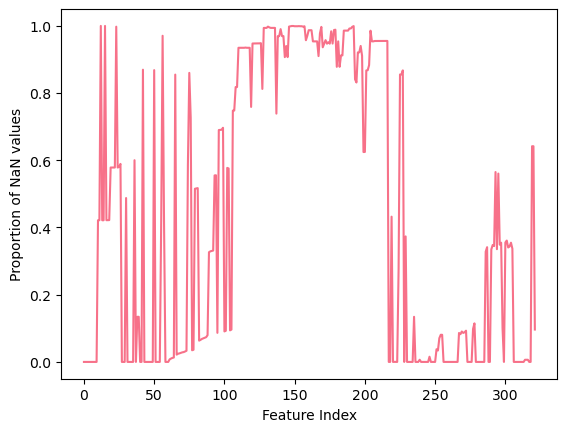

In [14]:
plt.plot(info_arr[:,0],info_arr[:,1])
plt.xlabel('Feature Index')
plt.ylabel('Proportion of NaN values')
plt.show()

## 10) Summary of findings

Summarize dataset sizes, feature type counts, missing-value totals and basic target information. Use this to plan preprocessing steps (imputation, encoding, scaling) and modeling choices.

In [ ]:
# Summary of findings
print("=== EDA SUMMARY ===")
print(f"Dataset Overview:")
print(f"- Training samples: {len(x_train)}")
print(f"- Test samples: {len(x_test)}")
print(f"- Total features: {len(x_train.columns)}")
print(f"- Continuous features: {len(feature_types['continuous'])}")
print(f"- Categorical features: {len(feature_types['categorical'])}")

# Missing values summary
total_missing_train = x_train.isnull().sum().sum()
total_missing_test = x_test.isnull().sum().sum()
print(f"\nData Quality:")
print(f"- Missing values in training: {total_missing_train}")
print(f"- Missing values in test: {total_missing_test}")

if total_missing_train > 0 or total_missing_test > 0:
    features_with_missing = missing_df[(missing_df['Train_Missing'] > 0) | (missing_df['Test_Missing'] > 0)]['Feature'].tolist()
    print(f"- Features with missing values: {features_with_missing}")

print(f"\nTarget Variable:")
print(f"- Unique target values: {target_values.nunique()}")
if target_values.nunique() <= 10:
    print(f"- Target distribution: {dict(target_values.value_counts())}")

### Ola ML function implementation

Initial implementation - select a random feature and implement the function. Pick feature #27.

In [22]:
print(np.where(info_arr[:,1]<0.1))

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  27,  28,  29,
        31,  32,  33,  34,  35,  37,  40,  41,  43,  44,  45,  46,  47,
        48,  49,  51,  52,  53,  54,  58,  59,  60,  61,  62,  63,  64,
        66,  67,  68,  69,  70,  71,  72,  73,  77,  78,  82,  83,  84,
        85,  86,  87,  88,  95, 100, 101, 104, 105, 217, 218, 220, 221,
       222, 223, 228, 230, 231, 232, 233, 234, 236, 237, 238, 239, 240,
       241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253,
       254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266,
       267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 279, 280,
       281, 282, 283, 284, 285, 288, 289, 299, 306, 307, 308, 309, 310,
       311, 312, 313, 314, 315, 316, 317, 318, 321]),)


In [23]:
# selected feature
labels[31]

'HLTHPLN1'

Loss function

In [24]:
def compute_loss(y, tx, w):
    """Calculate the loss using either MSE or MAE.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2,). The vector of model parameters.

    Returns:
        the value of the loss (a scalar), corresponding to the input parameters w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute loss by MSE
    factor=1/(2*y.shape[0])
    main=np.sum((y-(tx@w))**2)
    l=factor*main
    
    # ***************************************************

    return l

Define SGD function.

In [28]:
def compute_stoch_gradient(y, tx, w):
    """Compute a stochastic gradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the stochastic gradient of the loss at w.
    """

    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: implement stochastic gradient computation. It's the same as the usual gradient.
    gradient=(-1/y.shape[0])*(tx.T@(y-(tx@w)))
    # ***************************************************
    return gradient


def stochastic_gradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """The Stochastic Gradient Descent algorithm (SGD).

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic gradient
        max_iters: a scalar denoting the total number of iterations of SGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: implement stochastic gradient descent.

        #########regular gradient descent
        ##### I need to randomly chose a sub batch to compute gradient and randomize with every step
        ##### apart from this everything is the same
        # TODO: compute gradient and loss
        
        random_indices=np.random.randint(low=0, high=y.shape[0], size=(batch_size,))
        
        sample_y=y.T[random_indices]
        sample_tx=tx[random_indices]
        loss=compute_loss(sample_y, sample_tx, ws[n_iter])
        losses.append(loss)
        gradient=compute_stoch_gradient(sample_y, sample_tx, ws[n_iter])
        w_new=ws[n_iter]-gamma*gradient
        ws.append(w_new)
        ##############


        
        # ***************************************************


        print(
            "SGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [51]:
# assuming a linear relationship 
# y= w0 + w1*x
# y is the presence of the ilness
# x is the value of the selected feature
# need to prep tx matrix
x=x_train[:,31]
y=y_train[:,1]
ones = np.ones((x.shape[0],))
tx=(np.vstack((ones, x))).T

In [41]:
o=np.array([1,2,3])
b=np.array([4,5,6])

In [45]:
print(np.vstack((o,b)))

[[1 2 3]
 [4 5 6]]


In [53]:
print(y.shape)
print(x.shape[0])
print(tx.shape)

(328135,)
328135
(328135, 2)


In [54]:
import datetime
# from stochastic_gradient_descent import *

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.1
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SGD.
start_time = datetime.datetime.now()
sgd_losses, sgd_ws = stochastic_gradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SGD: execution time={t:.3f} seconds".format(t=exection_time))

SGD iter. 0/49: loss=0.5, w0=0, w1=0
SGD iter. 1/49: loss=0.24499999999999997, w0=0, w1=0
SGD iter. 2/49: loss=0.17405000000000004, w0=0, w1=0
SGD iter. 3/49: loss=0.11139199999999999, w0=0, w1=0
SGD iter. 4/49: loss=0.07129087999999997, w0=0, w1=0
SGD iter. 5/49: loss=0.04562616319999997, w0=0, w1=0
SGD iter. 6/49: loss=0.02920074444799997, w0=0, w1=0
SGD iter. 7/49: loss=0.018688476446720007, w0=0, w1=0
SGD iter. 8/49: loss=0.011960624925900812, w0=0, w1=0
SGD iter. 9/49: loss=0.0076547999525765084, w0=0, w1=0
SGD iter. 10/49: loss=0.07469948847571013, w0=0, w1=0
SGD iter. 11/49: loss=0.023100045850978808, w0=0, w1=0
SGD iter. 12/49: loss=0.01478402934462643, w0=0, w1=0
SGD iter. 13/49: loss=0.009461778780560915, w0=0, w1=0
SGD iter. 14/49: loss=0.006055538419558991, w0=0, w1=0
SGD iter. 15/49: loss=0.003875544588517758, w0=0, w1=0
SGD iter. 16/49: loss=0.002480348536651365, w0=0, w1=0
SGD iter. 17/49: loss=0.0015874230634568723, w0=0, w1=0
SGD iter. 18/49: loss=0.0010159507606123963

In [56]:
print(sgd_losses)

[np.float64(0.5), np.float64(0.24499999999999997), np.float64(0.17405000000000004), np.float64(0.11139199999999999), np.float64(0.07129087999999997), np.float64(0.04562616319999997), np.float64(0.02920074444799997), np.float64(0.018688476446720007), np.float64(0.011960624925900812), np.float64(0.0076547999525765084), np.float64(0.07469948847571013), np.float64(0.023100045850978808), np.float64(0.01478402934462643), np.float64(0.009461778780560915), np.float64(0.006055538419558991), np.float64(0.003875544588517758), np.float64(0.002480348536651365), np.float64(0.0015874230634568723), np.float64(0.0010159507606123963), np.float64(0.0006502084867919344), np.float64(0.00041613343154683934), np.float64(0.00026632539618997615), np.float64(0.0001704482535615839), np.float64(0.00010908688227941305), np.float64(6.981560465882488e-05), np.float64(4.468198698164771e-05), np.float64(0.1271743823390794), np.float64(0.012618504980916665), np.float64(0.008075843187786659), np.float64(0.00516853964018

In [65]:
from grid_search import generate_w, get_best_parameters, grid_search
from plots import grid_visualization

# Generate the grid of parameters to be swept
grid_w0, grid_w1 = generate_w(num_intervals=10)

# Start the grid search
start_time = datetime.datetime.now()
grid_losses = grid_search(y, tx, grid_w0, grid_w1)

ImportError: cannot import name 'grid_search' from 'grid_search' (c:\Users\aleks\ML\assignment_1\project-1-ai_force\grid_search.py)

In [59]:
# Time Visualization
from ipywidgets import IntSlider, interact
from plots import gradient_descent_visualization


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        sgd_losses,
        sgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)
    plt.show()


interact(plot_figure, n_iter=IntSlider(min=1, max=len(sgd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>